# Unsupervised Clustering — MEBeauty Dataset

Clusters faces from the MEBeauty dataset (which has rich ethnicity labels across 6 groups)
based solely on numeric geometric and expression features, then evaluates whether
discovered clusters align with gender or ethnicity.

In [1]:
# Parameters cell (papermill will inject values here)
data_path = "data/features.csv"
output_dir = "data/plots/clustering_mebeauty"

In [2]:
# Parameters
data_path = "data/features.csv"
output_dir = "data/plots/clustering_mebeauty"


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 120

out = Path(output_dir)
out.mkdir(parents=True, exist_ok=True)
print("Setup complete.")

Setup complete.


## 1. Load and Prepare Data (MEBeauty only)

In [4]:
df_all = pd.read_csv(data_path)
df = df_all[df_all["dataset"] == "mebeauty"].copy()
print(f"MEBeauty subset: {len(df)} samples")
print(f"\nGender distribution:\n{df['gender'].value_counts()}")
print(f"\nEthnicity distribution:\n{df['ethnicity'].value_counts()}")

MEBeauty subset: 2370 samples

Gender distribution:
gender
female    1337
male      1033
Name: count, dtype: int64

Ethnicity distribution:
ethnicity
caucasian     980
asian         351
hispanic      296
black         296
mideastern    291
indian        156
Name: count, dtype: int64


In [5]:
GEOMETRY_FEATURES = [
    "canthal_tilt", "eye_width_ratio", "eye_height_ratio", "eyebrow_eye_dist",
    "eye_spacing_ratio", "eye_area_ratio", "scleral_show", "eye_asymmetry",
    "brow_arch_height", "nose_width_ratio", "nose_length_ratio", "nose_symmetry",
    "lip_width_ratio", "upper_lip_ratio", "lip_fullness_ratio",
    "mouth_width_face_ratio", "cupids_bow_ratio", "mouth_chin_ratio",
    "mouth_symmetry", "facial_symmetry", "face_length_width_ratio",
    "jaw_width_ratio", "interpupillary_ratio", "gonial_angle", "chin_taper",
    "eye_symmetry", "midface_ratio", "lower_face_ratio", "phi_deviation",
    "facial_thirds_symmetry",
]

EXPRESSION_FEATURES = [
    "expr_smile", "expr_frown", "expr_jaw_open", "expr_brow_up",
    "expr_brow_down", "expr_cheek_squint", "expr_eye_squint",
    "expr_eye_wide", "expr_mouth_pucker",
]

FEATURE_COLS = GEOMETRY_FEATURES + EXPRESSION_FEATURES

df_clean = df.dropna(subset=FEATURE_COLS).copy()
print(f"Rows after dropping NaNs: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

scaler = StandardScaler()
X = scaler.fit_transform(df_clean[FEATURE_COLS])
print(f"Feature matrix shape: {X.shape}")

Rows after dropping NaNs: 2370 (dropped 0)
Feature matrix shape: (2370, 39)


## 2. PCA Visualization with Ground Truth

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_clean = df_clean.copy()
df_clean["pca_1"] = X_pca[:, 0]
df_clean["pca_2"] = X_pca[:, 1]

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}, "
      f"Total={sum(pca.explained_variance_ratio_):.3f}")

pca_full = PCA(n_components=0.95)
X_pca_full = pca_full.fit_transform(X)
print(f"PCA components for 95% variance: {pca_full.n_components_}")

Explained variance: PC1=0.224, PC2=0.161, Total=0.384
PCA components for 95% variance: 19


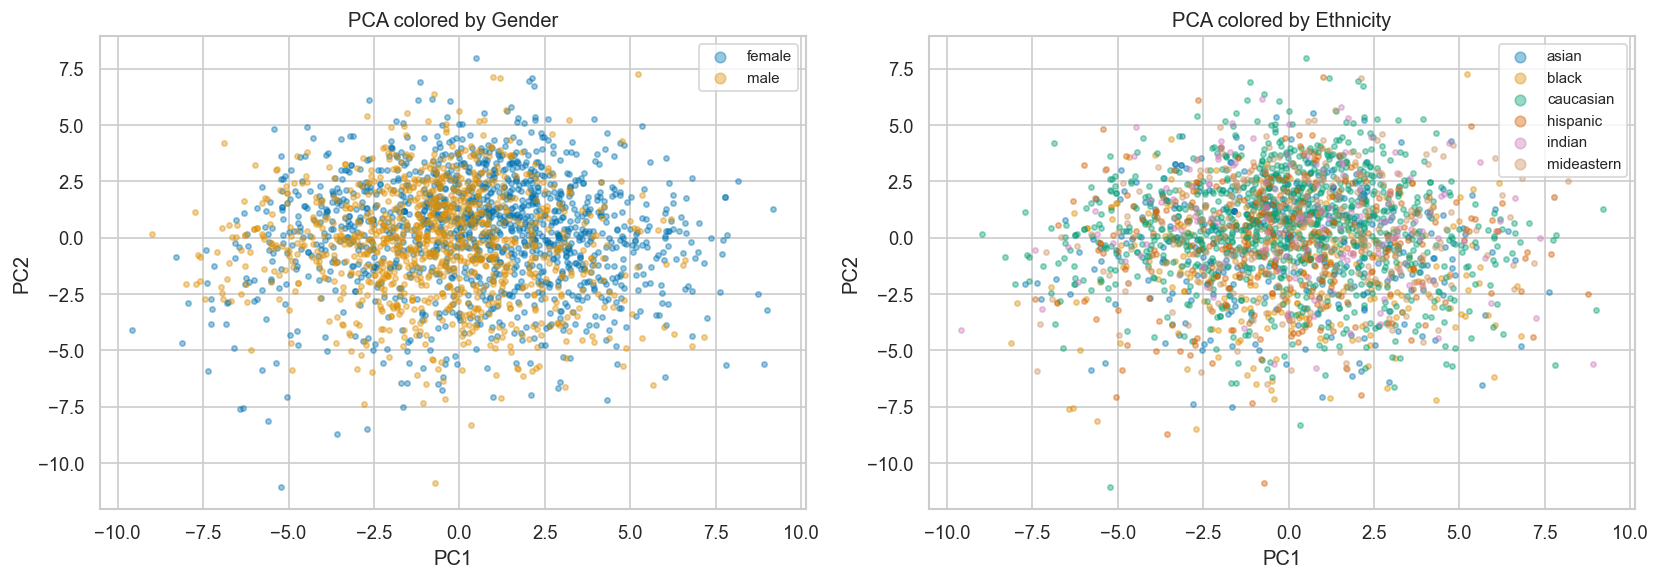

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ["gender", "ethnicity"], ["Gender", "Ethnicity"]):
    for label in sorted(df_clean[col].unique()):
        mask = df_clean[col] == label
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=10, label=label)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"PCA colored by {title}")
    ax.legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.savefig(out / "pca_ground_truth.png", bbox_inches="tight")
plt.show()

## 3. Optimal k (Elbow & Silhouette)

In [8]:
k_range = range(2, 15)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, random_state=42))
    print(f"  k={k:2d}: inertia={km.inertia_:.0f}, silhouette={silhouettes[-1]:.4f}")

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"\nBest k by silhouette: {best_k} (score={max(silhouettes):.4f})")

  k= 2: inertia=79337, silhouette=0.1503
  k= 3: inertia=70079, silhouette=0.1550


  k= 4: inertia=64025, silhouette=0.1326
  k= 5: inertia=61028, silhouette=0.1063
  k= 6: inertia=58662, silhouette=0.1086


  k= 7: inertia=56462, silhouette=0.1108
  k= 8: inertia=54790, silhouette=0.1019
  k= 9: inertia=53226, silhouette=0.1009


  k=10: inertia=51812, silhouette=0.1030
  k=11: inertia=50631, silhouette=0.0971


  k=12: inertia=49659, silhouette=0.0927
  k=13: inertia=48439, silhouette=0.0900
  k=14: inertia=47587, silhouette=0.0880

Best k by silhouette: 3 (score=0.1550)


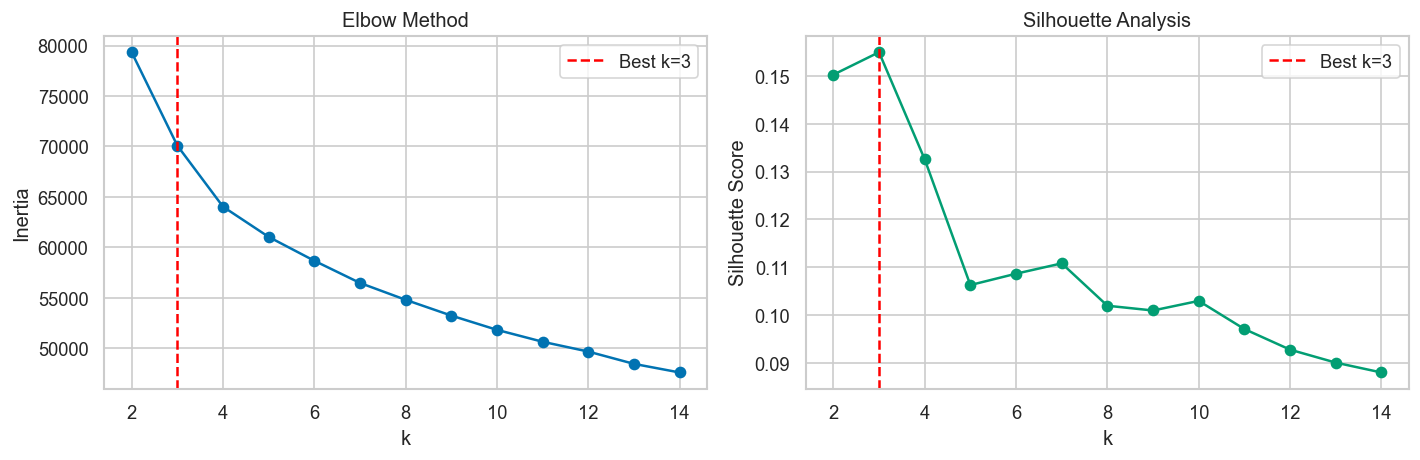

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(k_range), inertias, "bo-")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")
ax1.axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
ax1.legend()

ax2.plot(list(k_range), silhouettes, "go-")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Analysis")
ax2.axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
ax2.legend()

plt.tight_layout()
plt.savefig(out / "elbow_silhouette.png", bbox_inches="tight")
plt.show()

## 4. KMeans Clustering

In [10]:
n_genders = df_clean["gender"].nunique()      # 2
n_ethnicities = df_clean["ethnicity"].nunique()  # 6

print(f"Category counts -> Gender: {n_genders}, Ethnicity: {n_ethnicities}")
print(f"Optimal k by silhouette: {best_k}")

k_values = sorted(set([best_k, n_genders, n_ethnicities]))
kmeans_results = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    df_clean[f"kmeans_k{k}"] = labels
    kmeans_results[k] = labels
    sil = silhouette_score(X, labels, random_state=42)
    print(f"  KMeans k={k}: silhouette={sil:.4f}")

Category counts -> Gender: 2, Ethnicity: 6
Optimal k by silhouette: 3
  KMeans k=2: silhouette=0.1503
  KMeans k=3: silhouette=0.1550


  KMeans k=6: silhouette=0.1086


## 5. DBSCAN Clustering

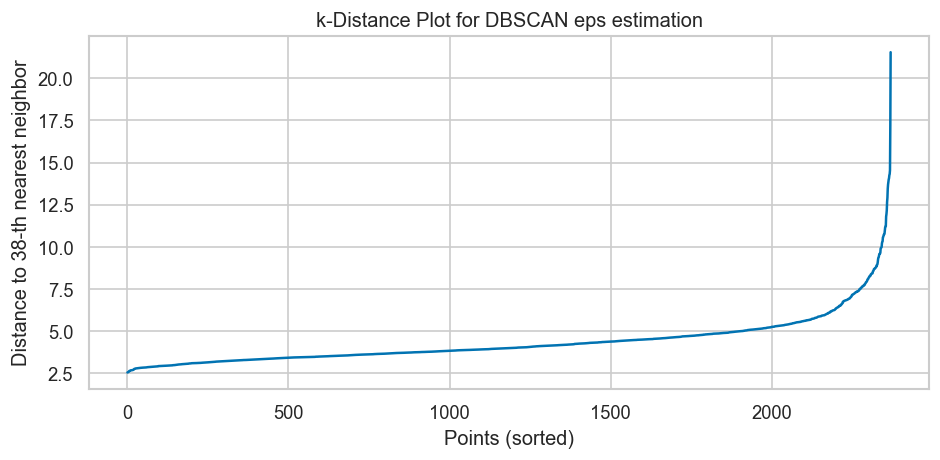

Estimated eps (90th percentile): 5.751


In [11]:
nn = NearestNeighbors(n_neighbors=2 * X_pca_full.shape[1])
nn.fit(X_pca_full)
distances, _ = nn.kneighbors(X_pca_full)
distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distances)
ax.set_xlabel("Points (sorted)")
ax.set_ylabel(f"Distance to {2 * X_pca_full.shape[1]}-th nearest neighbor")
ax.set_title("k-Distance Plot for DBSCAN eps estimation")
plt.tight_layout()
plt.savefig(out / "dbscan_kdist.png", bbox_inches="tight")
plt.show()

eps_candidate = float(np.percentile(distances, 90))
print(f"Estimated eps (90th percentile): {eps_candidate:.3f}")

In [12]:
dbscan = DBSCAN(eps=eps_candidate, min_samples=2 * X_pca_full.shape[1])
dbscan_labels = dbscan.fit_predict(X_pca_full)
df_clean["dbscan"] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
print(f"DBSCAN found {n_clusters_dbscan} clusters, {n_noise} noise points ({n_noise/len(dbscan_labels)*100:.1f}%)")

if n_clusters_dbscan > 1:
    mask_no_noise = dbscan_labels != -1
    sil = silhouette_score(X_pca_full[mask_no_noise], dbscan_labels[mask_no_noise], random_state=42)
    print(f"Silhouette (excl. noise): {sil:.4f}")
else:
    print("DBSCAN found <= 1 cluster; skipping silhouette.")

DBSCAN found 1 clusters, 84 noise points (3.5%)
DBSCAN found <= 1 cluster; skipping silhouette.


## 6. Hierarchical (Agglomerative) Clustering

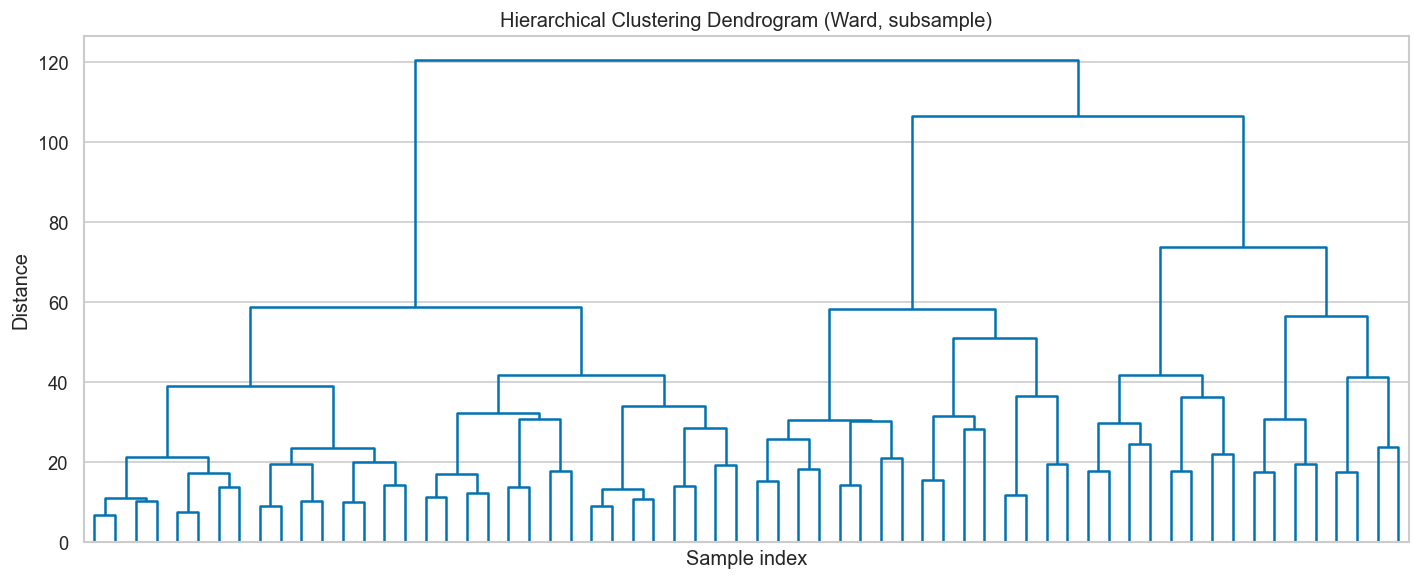

In [13]:
sample_idx = np.random.default_rng(42).choice(len(X), size=min(1500, len(X)), replace=False)
X_sample = X[sample_idx]

linkage_matrix = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode="level", p=5, ax=ax,
           no_labels=True, color_threshold=0)
ax.set_title("Hierarchical Clustering Dendrogram (Ward, subsample)")
ax.set_xlabel("Sample index")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.savefig(out / "dendrogram.png", bbox_inches="tight")
plt.show()

In [14]:
agglo_results = {}
for k in k_values:
    agglo = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agglo.fit_predict(X)
    df_clean[f"agglo_k{k}"] = labels
    agglo_results[k] = labels
    sil = silhouette_score(X, labels, random_state=42)
    print(f"Agglomerative k={k}: silhouette={sil:.4f}")

Agglomerative k=2: silhouette=0.1512
Agglomerative k=3: silhouette=0.0899
Agglomerative k=6: silhouette=0.0955


## 7. Cluster vs. Category Alignment

- **Adjusted Rand Index (ARI)**: 1.0 = perfect match, 0.0 = random
- **Normalized Mutual Information (NMI)**: 1.0 = perfect correlation, 0.0 = independent

In [15]:
categories = {
    "gender": LabelEncoder().fit_transform(df_clean["gender"]),
    "ethnicity": LabelEncoder().fit_transform(df_clean["ethnicity"]),
}

results = []

for k, labels in kmeans_results.items():
    for cat_name, cat_labels in categories.items():
        ari = adjusted_rand_score(cat_labels, labels)
        nmi = normalized_mutual_info_score(cat_labels, labels)
        results.append({"algorithm": "KMeans", "k": k, "category": cat_name, "ARI": ari, "NMI": nmi})

for k, labels in agglo_results.items():
    for cat_name, cat_labels in categories.items():
        ari = adjusted_rand_score(cat_labels, labels)
        nmi = normalized_mutual_info_score(cat_labels, labels)
        results.append({"algorithm": "Agglomerative", "k": k, "category": cat_name, "ARI": ari, "NMI": nmi})

if n_clusters_dbscan > 1:
    mask_no_noise = dbscan_labels != -1
    for cat_name, cat_labels in categories.items():
        ari = adjusted_rand_score(cat_labels[mask_no_noise], dbscan_labels[mask_no_noise])
        nmi = normalized_mutual_info_score(cat_labels[mask_no_noise], dbscan_labels[mask_no_noise])
        results.append({"algorithm": "DBSCAN", "k": n_clusters_dbscan, "category": cat_name, "ARI": ari, "NMI": nmi})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

    algorithm  k  category      ARI      NMI
       KMeans  2    gender 0.029416 0.016506
       KMeans  2 ethnicity 0.002024 0.001553
       KMeans  3    gender 0.002813 0.009418
       KMeans  3 ethnicity 0.016493 0.005067
       KMeans  6    gender 0.061706 0.066692
       KMeans  6 ethnicity 0.023140 0.028272
Agglomerative  2    gender 0.005896 0.001586
Agglomerative  2 ethnicity 0.007619 0.003250
Agglomerative  3    gender 0.001841 0.001218
Agglomerative  3 ethnicity 0.005814 0.010900
Agglomerative  6    gender 0.016799 0.024954
Agglomerative  6 ethnicity 0.024135 0.018774


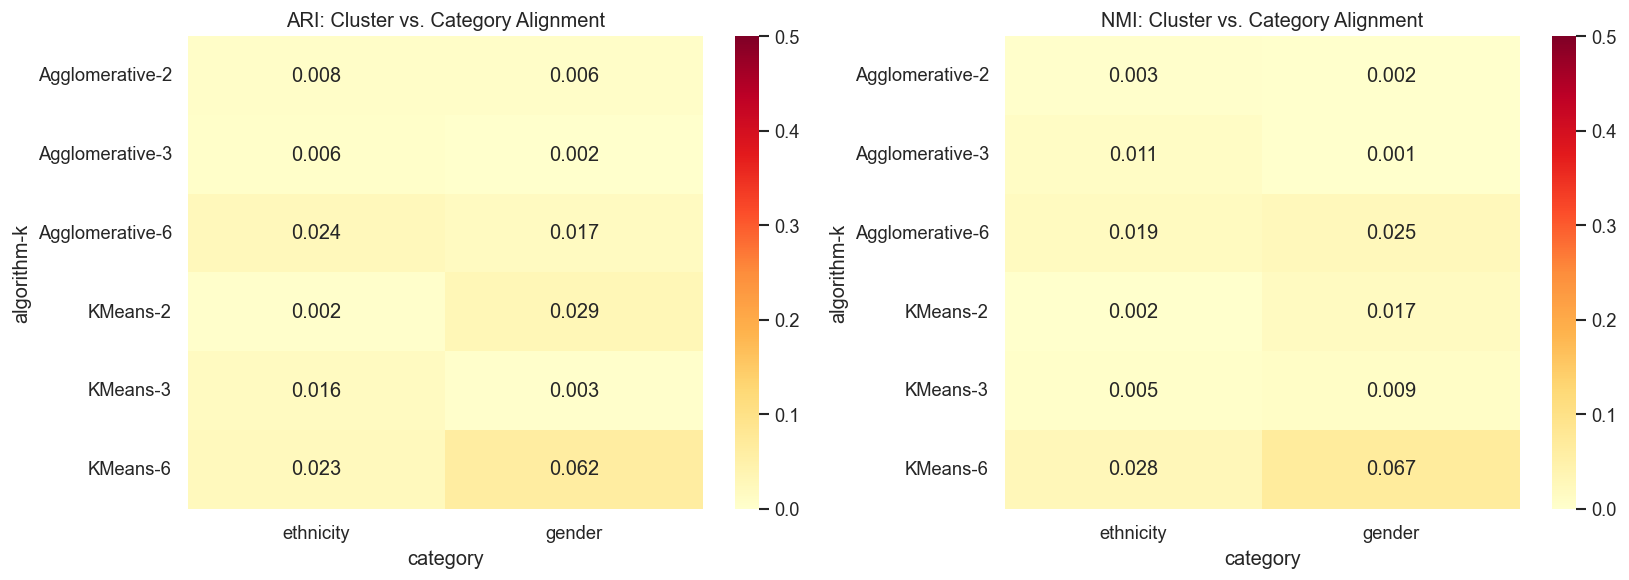

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip([ax1, ax2], ["ARI", "NMI"]):
    pivot = results_df.pivot_table(index=["algorithm", "k"], columns="category", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax, vmin=0, vmax=0.5)
    ax.set_title(f"{metric}: Cluster vs. Category Alignment")

plt.tight_layout()
plt.savefig(out / "alignment_heatmap.png", bbox_inches="tight")
plt.show()

## 8. Detailed Cross-Tabulations


KMeans k=2 vs gender (row-normalized):
kmeans_k2      0      1
gender                 
female     0.690  0.310
male       0.544  0.456


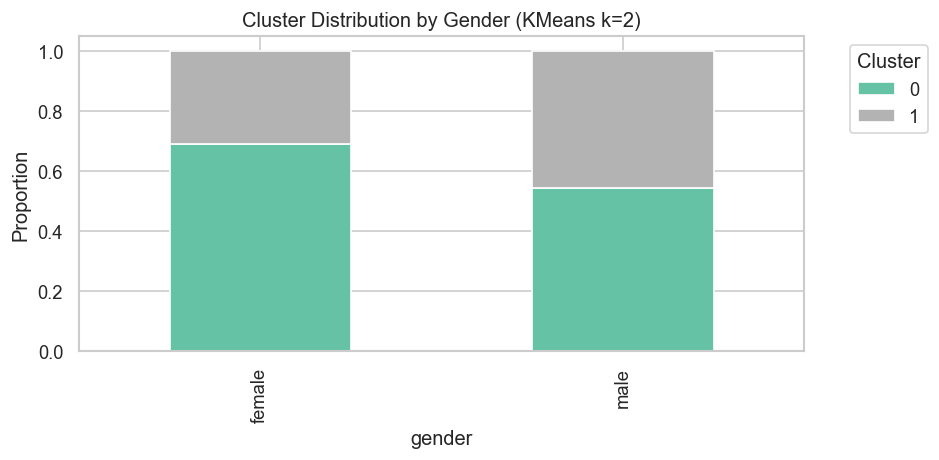


KMeans k=6 vs ethnicity (row-normalized):
kmeans_k6       0      1      2      3      4      5
ethnicity                                           
asian       0.057  0.228  0.182  0.205  0.185  0.142
black       0.044  0.145  0.169  0.375  0.216  0.051
caucasian   0.015  0.281  0.174  0.126  0.150  0.254
hispanic    0.027  0.189  0.176  0.243  0.182  0.182
indian      0.032  0.288  0.244  0.135  0.192  0.109
mideastern  0.021  0.275  0.227  0.137  0.100  0.241


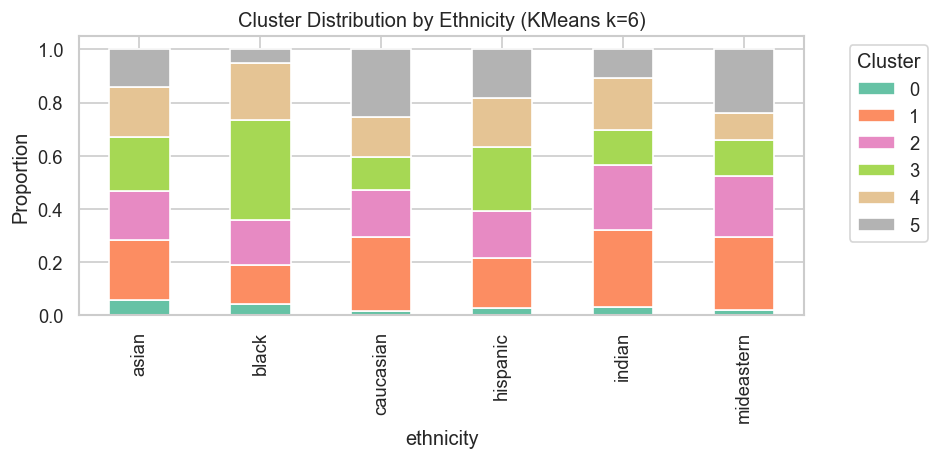

In [17]:
for cat_name, n_cat in [("gender", n_genders), ("ethnicity", n_ethnicities)]:
    col = f"kmeans_k{n_cat}"
    if col not in df_clean.columns:
        continue
    ct = pd.crosstab(df_clean[cat_name], df_clean[col], normalize="index")
    print(f"\n{'='*60}")
    print(f"KMeans k={n_cat} vs {cat_name} (row-normalized):")
    print(f"{'='*60}")
    print(ct.round(3).to_string())

    fig, ax = plt.subplots(figsize=(8, 4))
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
    ax.set_title(f"Cluster Distribution by {cat_name.title()} (KMeans k={n_cat})")
    ax.set_ylabel("Proportion")
    ax.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(out / f"crosstab_kmeans_{cat_name}.png", bbox_inches="tight")
    plt.show()

In [18]:
# Also show raw counts for ethnicity-matched clustering
col = f"kmeans_k{n_ethnicities}"
if col in df_clean.columns:
    ct_counts = pd.crosstab(df_clean["ethnicity"], df_clean[col])
    print("\nRaw counts (ethnicity vs cluster):")
    print(ct_counts.to_string())
    print(f"\nCluster sizes: {ct_counts.sum().to_dict()}")


Raw counts (ethnicity vs cluster):
kmeans_k6    0    1    2    3    4    5
ethnicity                              
asian       20   80   64   72   65   50
black       13   43   50  111   64   15
caucasian   15  275  171  123  147  249
hispanic     8   56   52   72   54   54
indian       5   45   38   21   30   17
mideastern   6   80   66   40   29   70

Cluster sizes: {0: 67, 1: 579, 2: 441, 3: 439, 4: 389, 5: 455}


## 9. PCA Visualization of Clusters

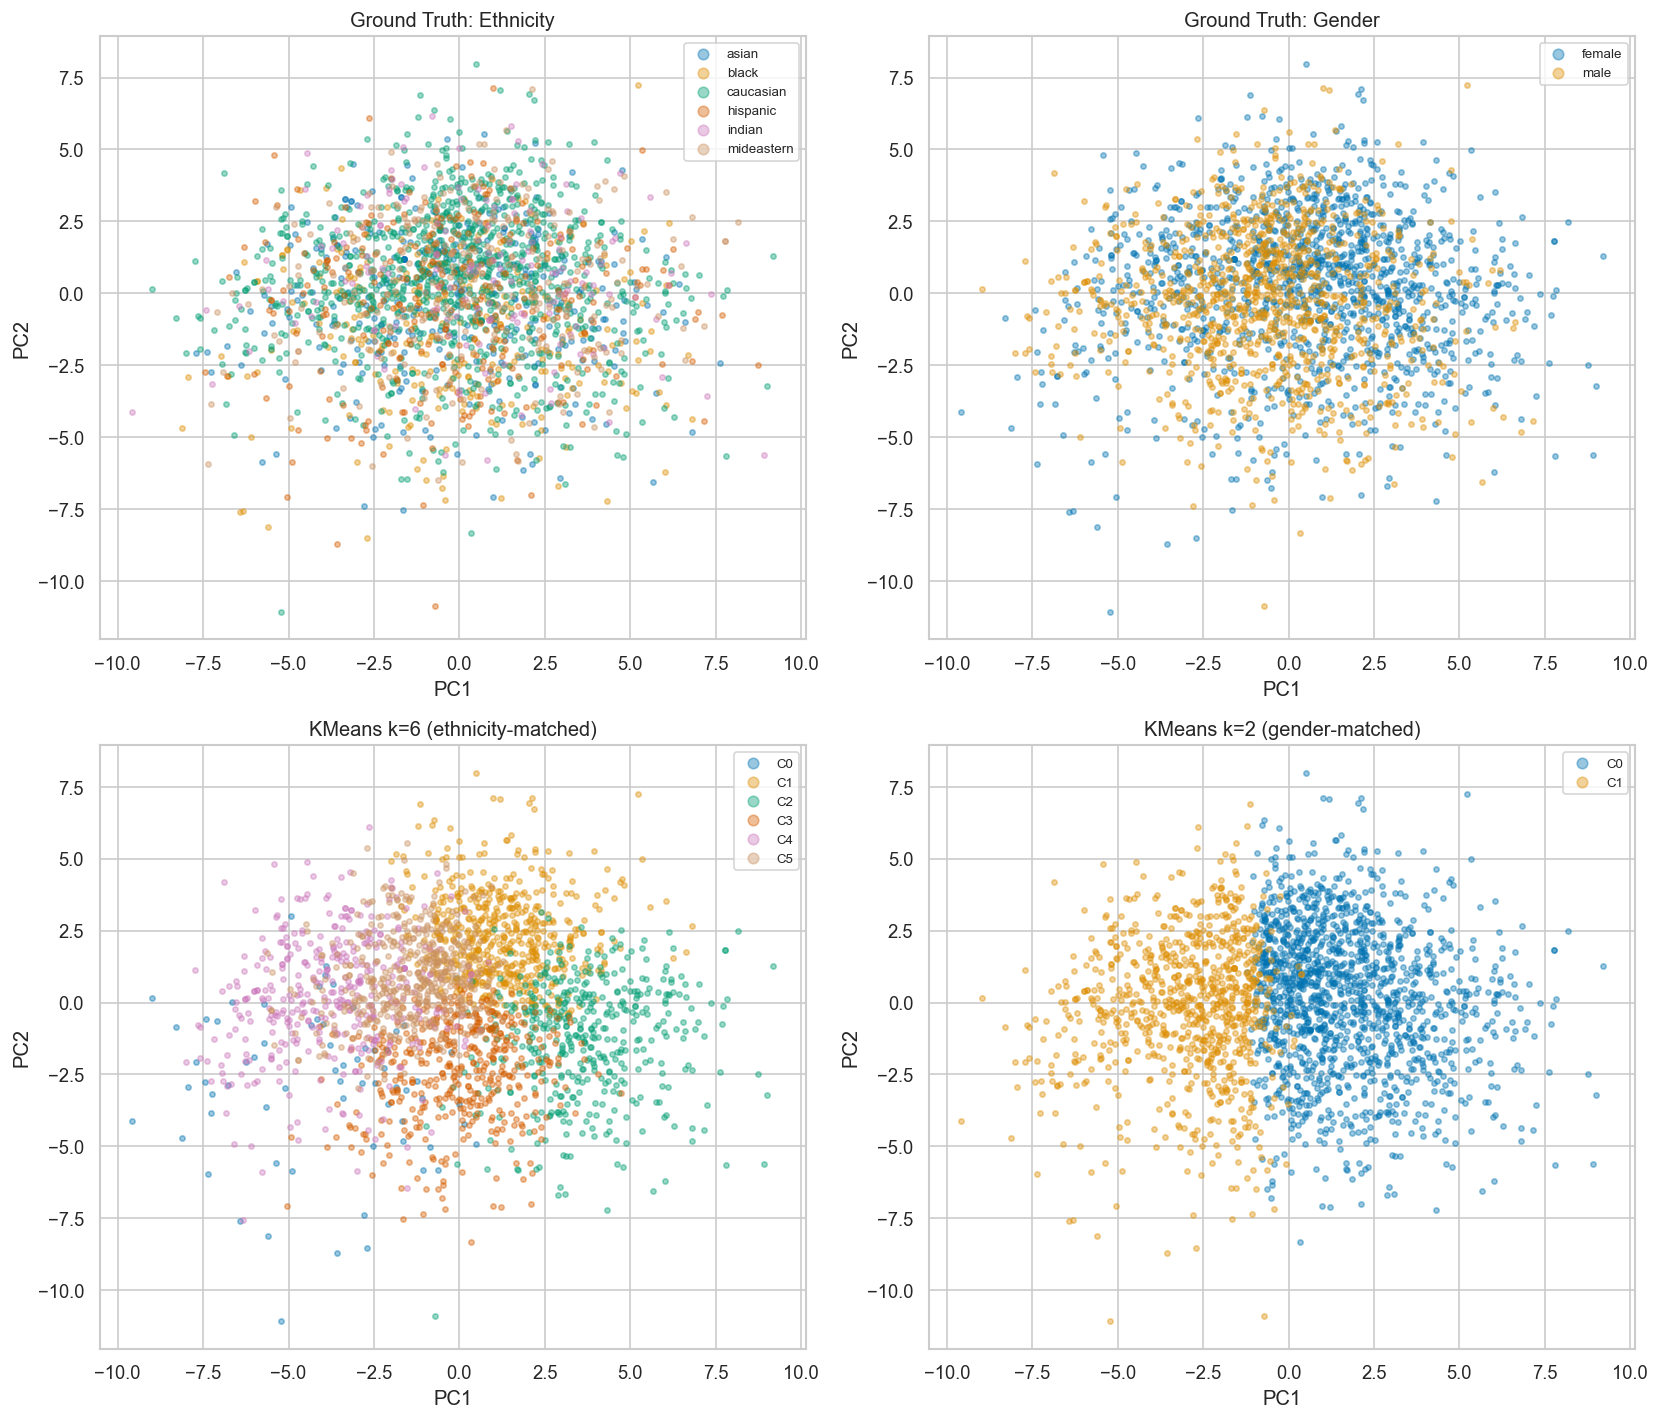

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Ground truth: ethnicity
ax = axes[0, 0]
for label in sorted(df_clean["ethnicity"].unique()):
    mask = df_clean["ethnicity"] == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=10, label=label)
ax.set_title("Ground Truth: Ethnicity")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(markerscale=2, fontsize=8)

# Ground truth: gender
ax = axes[0, 1]
for label in sorted(df_clean["gender"].unique()):
    mask = df_clean["gender"] == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=10, label=label)
ax.set_title("Ground Truth: Gender")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(markerscale=2, fontsize=8)

# KMeans k=ethnicity
ax = axes[1, 0]
col = f"kmeans_k{n_ethnicities}"
if col in df_clean.columns:
    for cluster in range(n_ethnicities):
        mask = df_clean[col] == cluster
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=10, label=f"C{cluster}")
ax.set_title(f"KMeans k={n_ethnicities} (ethnicity-matched)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(markerscale=2, fontsize=8)

# KMeans k=gender
ax = axes[1, 1]
col = f"kmeans_k{n_genders}"
if col in df_clean.columns:
    for cluster in range(n_genders):
        mask = df_clean[col] == cluster
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=10, label=f"C{cluster}")
ax.set_title(f"KMeans k={n_genders} (gender-matched)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.savefig(out / "pca_clusters_vs_truth.png", bbox_inches="tight")
plt.show()

## 10. Feature Importance per Cluster

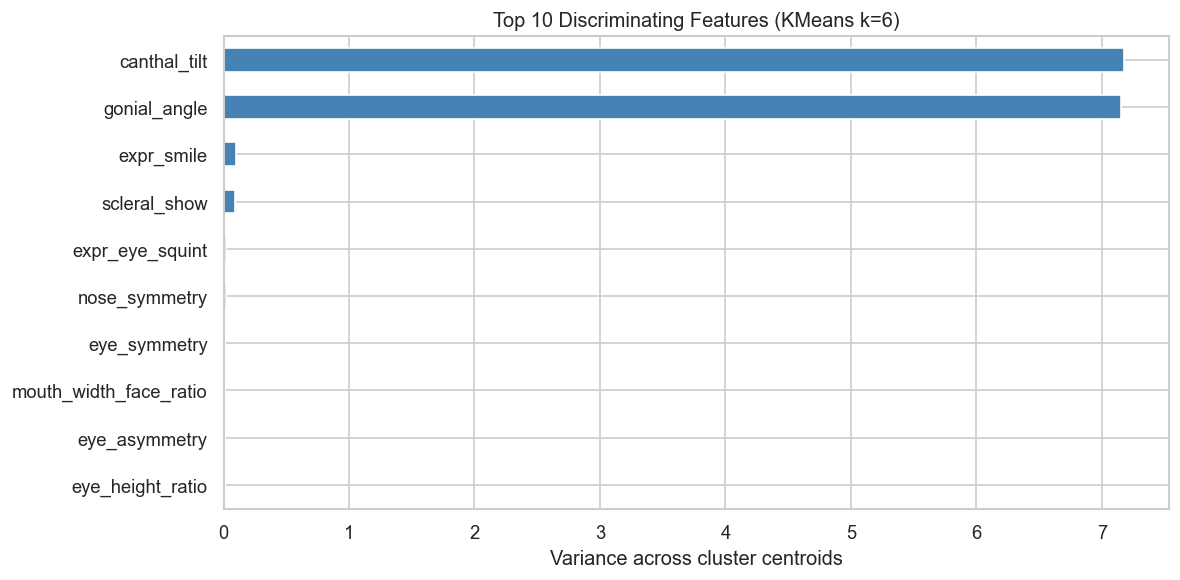


Cluster centroids (top features):
           canthal_tilt  gonial_angle  expr_smile  scleral_show  expr_eye_squint  nose_symmetry  eye_symmetry  mouth_width_face_ratio  eye_asymmetry  eye_height_ratio
kmeans_k6                                                                                                                                                             
0                0.8160      149.0654      0.4458       -0.8172           0.5575         0.1968        0.2155                  0.9401         0.2965            0.1199
1                7.7069      150.0541      0.0965       -0.0269           0.2859         0.1033        0.1273                  0.8081         0.0372            0.3740
2                6.3015      151.4481      0.0692       -0.0400           0.2239         0.4209        0.4001                  0.8205         0.0589            0.4055
3                1.7426      143.7071      0.0457       -0.1231           0.2284         0.1368        0.1436                  0.8

In [20]:
# Use ethnicity-matched KMeans
col = f"kmeans_k{n_ethnicities}"
cluster_means = df_clean.groupby(col)[FEATURE_COLS].mean()

centroid_var = cluster_means.var()
top_features = centroid_var.nlargest(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_features.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Variance across cluster centroids")
ax.set_title(f"Top 10 Discriminating Features (KMeans k={n_ethnicities})")
plt.tight_layout()
plt.savefig(out / "feature_importance_clusters.png", bbox_inches="tight")
plt.show()

print("\nCluster centroids (top features):")
print(cluster_means[top_features.index].round(4).to_string())

In [21]:
# Compare cluster centroids vs actual ethnicity group means
ethnicity_means = df_clean.groupby("ethnicity")[FEATURE_COLS].mean()
print("Actual ethnicity group means (top discriminating features):")
print(ethnicity_means[top_features.index].round(4).to_string())

Actual ethnicity group means (top discriminating features):
            canthal_tilt  gonial_angle  expr_smile  scleral_show  expr_eye_squint  nose_symmetry  eye_symmetry  mouth_width_face_ratio  eye_asymmetry  eye_height_ratio
ethnicity                                                                                                                                                              
asian             6.2707      147.2306      0.2278       -0.1696           0.3660         0.1778        0.1907                  0.8533         0.0630            0.3281
black             4.3037      148.9184      0.2642       -0.1415           0.2791         0.1686        0.1777                  0.9174         0.0673            0.3174
caucasian         5.1843      148.3023      0.1993       -0.1183           0.3707         0.1624        0.1716                  0.8676         0.0556            0.3398
hispanic          4.4761      147.8422      0.2368       -0.1314           0.3515         0.1663    

## 11. Summary

In [22]:
print("=" * 60)
print("CLUSTERING ANALYSIS SUMMARY (MEBeauty)")
print("=" * 60)
print(f"\nDataset: {len(df_clean)} samples, {len(FEATURE_COLS)} numeric features")
print(f"Demographics: {n_genders} genders, {n_ethnicities} ethnicities")
print(f"PCA: 2 components explain {sum(pca.explained_variance_ratio_)*100:.1f}% variance")
print(f"PCA: {pca_full.n_components_} components explain 95% variance")
print(f"\nOptimal k (silhouette): {best_k}")
print(f"DBSCAN clusters: {n_clusters_dbscan} (noise: {n_noise})")

print(f"\n{'\u2500'*60}")
print("Alignment Scores (higher = clusters match category better):")
print(f"{'\u2500'*60}")

for cat in ["gender", "ethnicity"]:
    cat_results = results_df[results_df["category"] == cat]
    best_row = cat_results.loc[cat_results["NMI"].idxmax()]
    print(f"\n  {cat.upper()}:")
    print(f"    Best: {best_row['algorithm']} k={int(best_row['k'])} "
          f"(ARI={best_row['ARI']:.3f}, NMI={best_row['NMI']:.3f})")

print(f"\n{'\u2500'*60}")
print("Interpretation:")
print("  ARI ~ 0 and NMI ~ 0: Clusters do NOT correspond to this category")
print("  ARI > 0.1 or NMI > 0.1: Some alignment exists")
print("  ARI > 0.3 or NMI > 0.3: Strong alignment")
print("=" * 60)

CLUSTERING ANALYSIS SUMMARY (MEBeauty)

Dataset: 2370 samples, 39 numeric features
Demographics: 2 genders, 6 ethnicities
PCA: 2 components explain 38.4% variance
PCA: 19 components explain 95% variance

Optimal k (silhouette): 3
DBSCAN clusters: 1 (noise: 84)

────────────────────────────────────────────────────────────
Alignment Scores (higher = clusters match category better):
────────────────────────────────────────────────────────────

  GENDER:
    Best: KMeans k=6 (ARI=0.062, NMI=0.067)

  ETHNICITY:
    Best: KMeans k=6 (ARI=0.023, NMI=0.028)

────────────────────────────────────────────────────────────
Interpretation:
  ARI ~ 0 and NMI ~ 0: Clusters do NOT correspond to this category
  ARI > 0.1 or NMI > 0.1: Some alignment exists
  ARI > 0.3 or NMI > 0.3: Strong alignment
